In [1]:
# Install OpenDatasets to download Kaggle dataset directly
!pip install -q opendatasets

In [2]:
# Import required libraries
import os
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import opendatasets as od

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# Download NEU Surface Defect Dataset from Kaggle
od.download("https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sbshreyaburande2002
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database


100%|██████████| 26.4M/26.4M [00:00<00:00, 179MB/s]

In [4]:
# Search for all image files inside /content
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
image_paths = []

for ext in image_extensions:
    image_paths.extend(glob.glob('/content/neu-surface-defect-database/**/*' + ext[1:], recursive=True))

# Remove files from hidden/system folders if any
image_paths = [p for p in image_paths if os.path.isfile(p)]

print("Total images found:", len(image_paths))
print("Sample image paths:")
for p in image_paths[:10]:
    print(p)

Total images found: 1800
Sample image paths:
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_246.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_259.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_241.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_294.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_296.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_252.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_255.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_262.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_269.jpg
/content/neu-surface-defect-database/NEU-DET/validation/images/crazing/crazing_265.jpg


In [5]:
# Function to infer defect class from filename or folder name
classes = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

def get_label(path):
    path_lower = path.lower().replace(' ', '_')
    for cls in classes:
        if cls in path_lower:
            return cls
    return None

labels = [get_label(p) for p in image_paths]

df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

# Keep only images where label could be detected
df = df.dropna().reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1800, 2)


,image_path,label
0,/content/neu-surface-defect-database/NEU-DET/v...,crazing
1,/content/neu-surface-defect-database/NEU-DET/v...,crazing
2,/content/neu-surface-defect-database/NEU-DET/v...,crazing
3,/content/neu-surface-defect-database/NEU-DET/v...,crazing
4,/content/neu-surface-defect-database/NEU-DET/v...,crazing


In [6]:
print("Classes:", sorted(df['label'].unique()))
print("Number of classes:", df['label'].nunique())
print("Total labelled images:", len(df))

df['label'].value_counts()

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of classes: 6
Total labelled images: 1800


,count
label,
crazing,300
scratches,300
inclusion,300
rolled-in_scale,300
pitted_surface,300
patches,300


In [7]:
print(df.isnull().sum())

image_path    0
label         0
dtype: int64


In [8]:
print("Duplicate image paths:", df.duplicated(subset=['image_path']).sum())
df = df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
print("Shape after duplicate removal:", df.shape)

Duplicate image paths: 0
Shape after duplicate removal: (1800, 2)


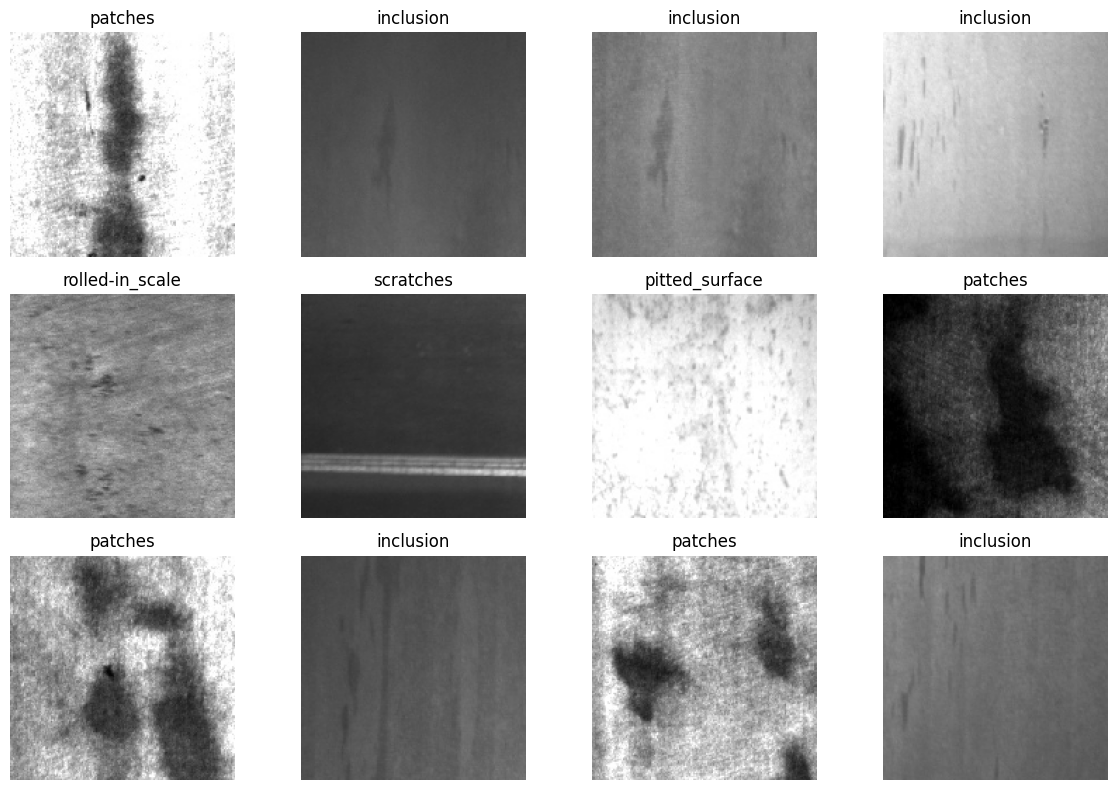

In [10]:
plt.figure(figsize=(12,8))
sample_df = df.sample(min(12, len(df)), random_state=42)

for i, row in enumerate(sample_df.itertuples(), 1):
    img = tf.keras.utils.load_img(row.image_path, target_size=(160,160))
    plt.subplot(3,4,i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

Training images: 1440
Validation images: 360


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='sparse',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='sparse',
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 1440 validated image filenames belonging to 6 classes.
Found 360 validated image filenames belonging to 6 classes.
Class indices: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [13]:
num_classes = df['label'].nunique()

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained layers
base_model.trainable = False

inputs = Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 15. Train Model

.

In [14]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8687 - loss: 0.4047 - val_accuracy: 0.9722 - val_loss: 0.1028
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9785 - loss: 0.0669 - val_accuracy: 0.9944 - val_loss: 0.0399
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9826 - loss: 0.0610 - val_accuracy: 0.9944 - val_loss: 0.0394
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.9840 - loss: 0.0390 - val_accuracy: 0.9694 - val_loss: 0.0638
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9958 - loss: 0.0206 - val_accuracy: 0.9944 - val_loss: 0.0327


In [15]:
val_loss, val_accuracy = model.evaluate(val_gen)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9944 - loss: 0.0327
Validation Loss: 0.03270220384001732
Validation Accuracy: 0.9944444298744202


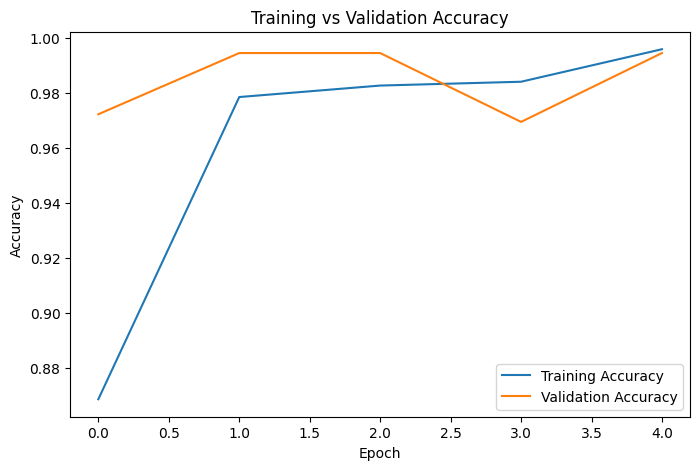

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

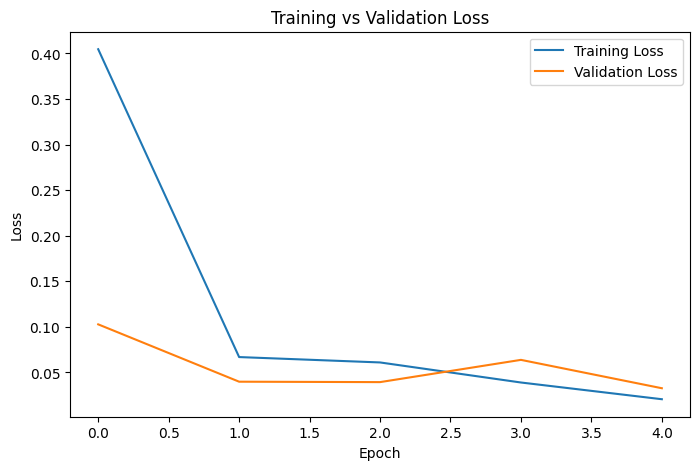

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
# Predict validation set
val_gen.reset()
y_prob = model.predict(val_gen)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes

# Class names in correct order
idx_to_class = {v:k for k,v in train_gen.class_indices.items()}
target_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)


12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
                 precision    recall  f1-score   support

        crazing       1.00      0.97      0.98        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       0.97      1.00      0.98        60
      scratches       1.00      1.00      1.00        60

       accuracy                           0.99       360
      macro avg       0.99      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


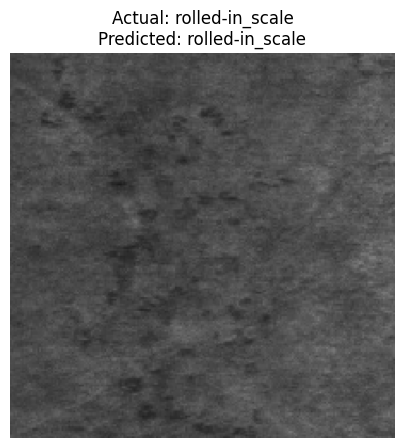

In [20]:
batch_images, batch_labels = next(val_gen)

predictions = model.predict(batch_images)

plt.figure(figsize=(5,5))

plt.imshow((batch_images[0] + 1) / 2)

actual = idx_to_class[int(batch_labels[0])]
predicted = idx_to_class[int(np.argmax(predictions[0]))]

plt.title(f"Actual: {actual}\nPredicted: {predicted}")

plt.axis('off')
plt.show()

In this project, I used the NEU Surface Defect Dataset and developed a MobileNetV2-based transfer learning model for defect classification. The model automatically learned visual features such as scratches, cracks, patches, and surface texture variations. After training and evaluation, the system was able to classify manufacturing defects automatically. This solution can be integrated into production lines to improve quality assurance, reduce manual inspection effort, and prevent defective products from reaching customers.